In [1]:
from inlist import target, PIPELINE_OPTIONS_OVERRIDE
from run_context import apply_context_globals
from abund_plot import run_step5_ele_abundance_plots

ctx = apply_context_globals(
    globals(),
    target=target,
    pipeline_options_override=PIPELINE_OPTIONS_OVERRIDE,
    prepare_io=True,
)

# 这个代码是为了画不同的abundance的图
- [X/H] sorted by 


### 首先在`output_abundances_result_path`读取raw results
- df: 由 output_abundances_result_path 读入并加工后的 DataFrame
    - 含所有电离态逐行记录
    - 已新增列：
        - base_element : 形如 "Fe 1" → "Fe"
        - ion          : 形如 "Fe 1" → 1（缺省时置为 1）
        - Z            : 原子序数（ATOMIC_Z 映射，缺失填 9999）
    - 未合并电离态（每个电离态仍为独立一行）
    - 未按 Tc 处理

- df_combined: 由 df 按 base_element 分组合并后的 DataFrame（元素层面）
    - 合并规则：
        - [X/H]       → 各电离态的均值
        - std_[X/H]   → 各电离态的均值（可按需改为 max 或 标准误）
        - n_lines     → 各电离态的和
    - 已新增列：
        - Z            : 原子序数（ATOMIC_Z 映射）
    - 不含电离态维度（每个元素仅一行）
    - 未按 Tc 处理

- order（内部变量）: 由 df 计算得到的 x 轴顺序（按 Z、ion、base_element、element 排序）
    - 用于把 df["element"] 设为有序 Categorical，保证绘图横轴稳定

- 绘图使用：
    - plot_with_ions(df)       → 区分电离态画图（x 轴为 element=“X ion”），顺序按 (Z, ion)
    - plot_combined(df_combined)→ 合并电离态画图（x 轴为 base_element），顺序按 Z

[STEP 1] Running step 5 abundance plotting pipeline.
[STEP 1] Loading abundance summary and preparing figure output folder.
[STEP 2] Building element and ion level tables (fig01/fig02).


/Users/jiayue/iSpec/Code/abund_plot.py:711: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined = df.groupby("base_element", as_index=False).apply(combine_ions_sem)


[STEP 3] Preparing Tc-based target tables and HFS flags.
[STEP 4] Building reference abundance table.
[STEP 5] Generating all abundance comparison plots.


/Users/jiayue/iSpec/Code/abund_plot.py:733: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined_hfs = df_summary_src.groupby("base_element", as_index=False).apply(combine_ions_sem)
/Users/jiayue/iSpec/Code/abund_plot.py:898: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = d.groupby("base_element", as_index=False).apply(combine_ions_sem)


[STEP 6] Step_element_abundance_plot completed. Output folder: /Users/jiayue/iSpec/output/MegantestSample/HIP18844/abundance_plots/
[STEP 2] Step_element_abundance_plot completed.
[STEP 2] Plot folder: /Users/jiayue/iSpec/output/MegantestSample/HIP18844/abundance_plots/


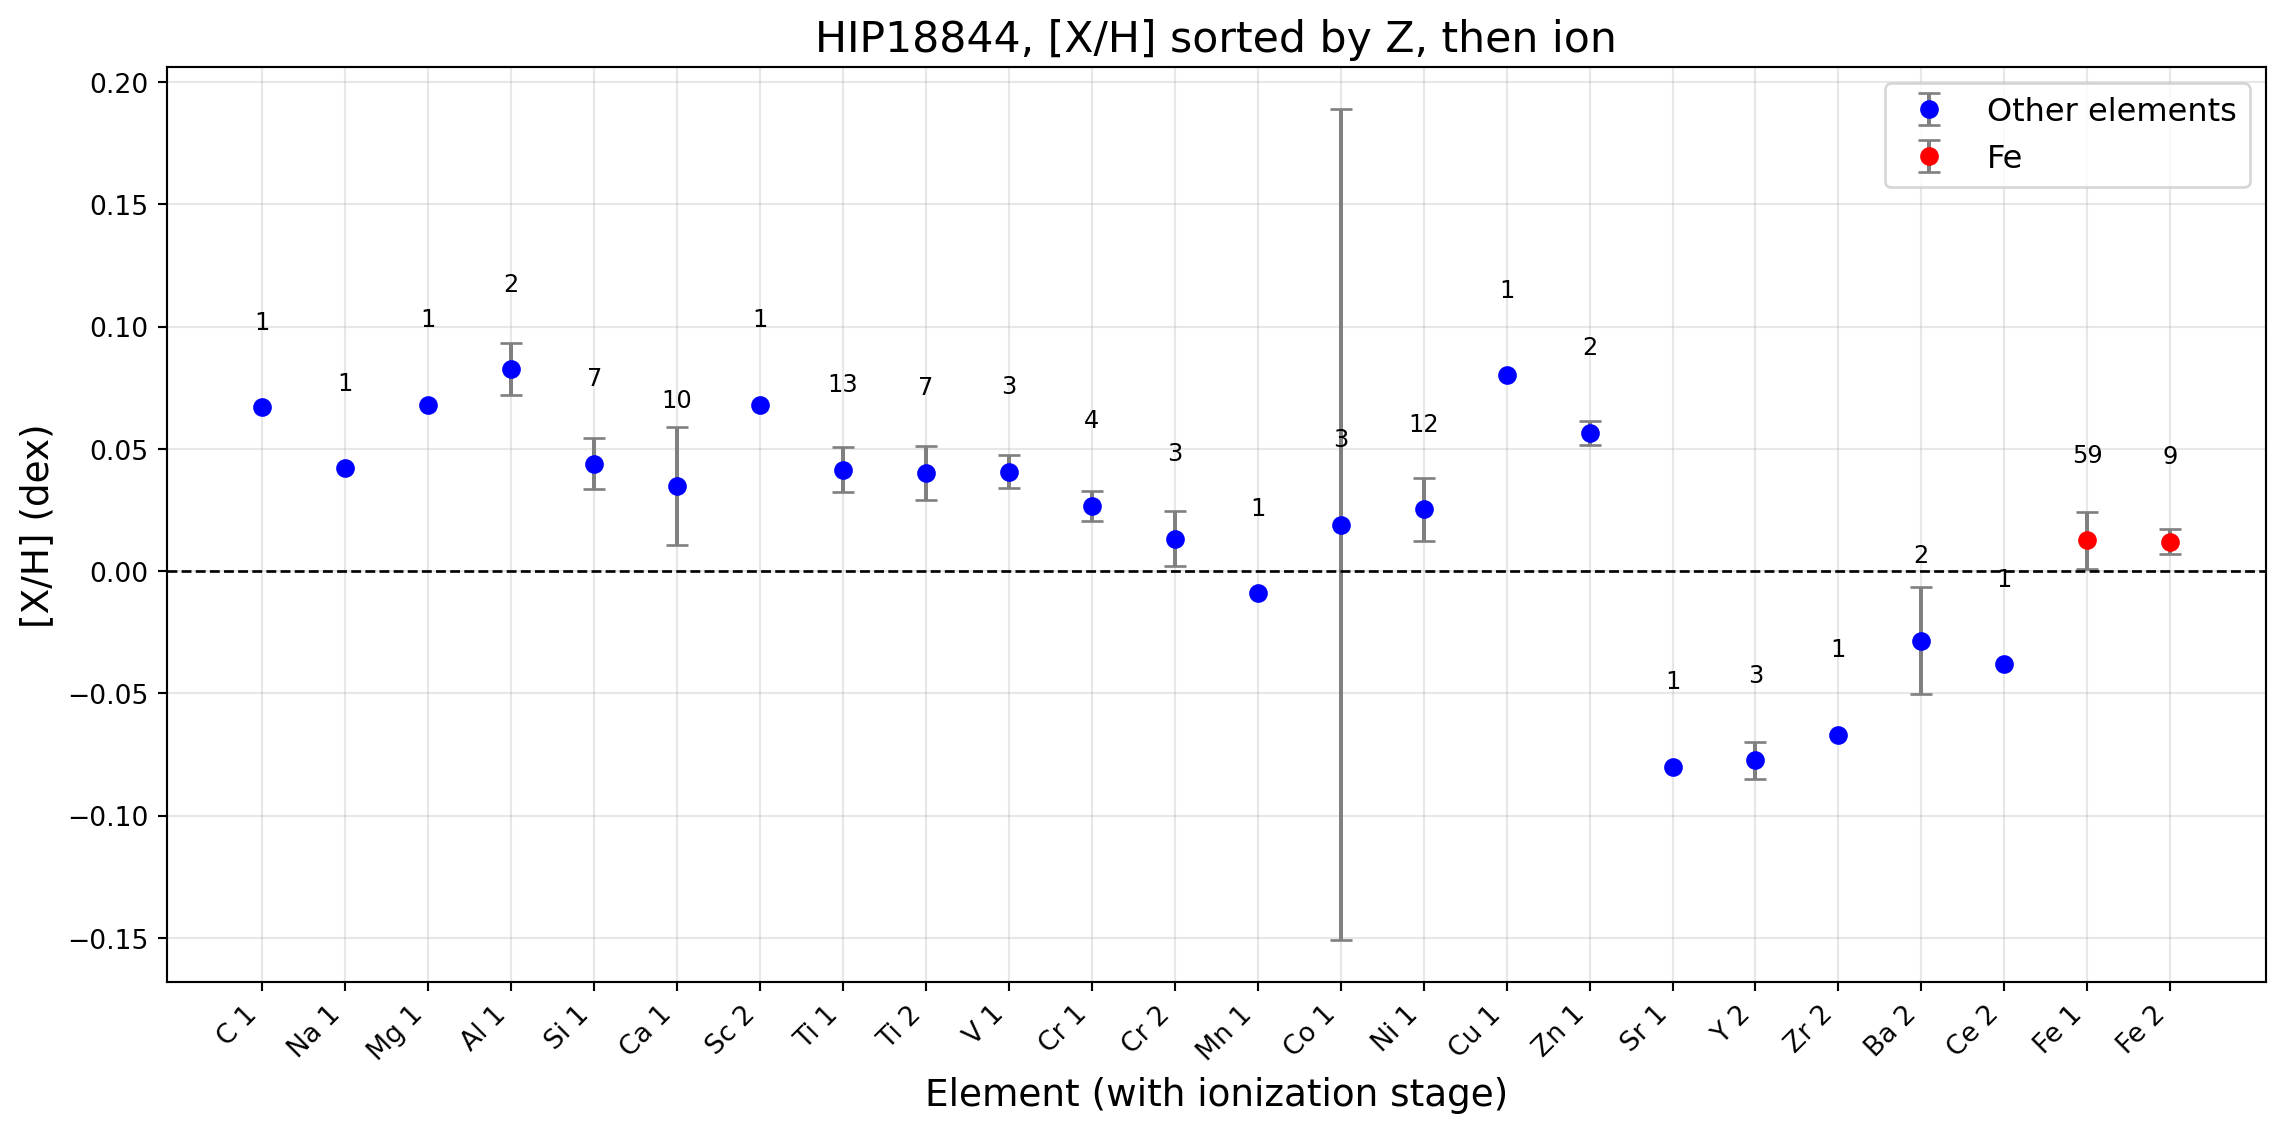

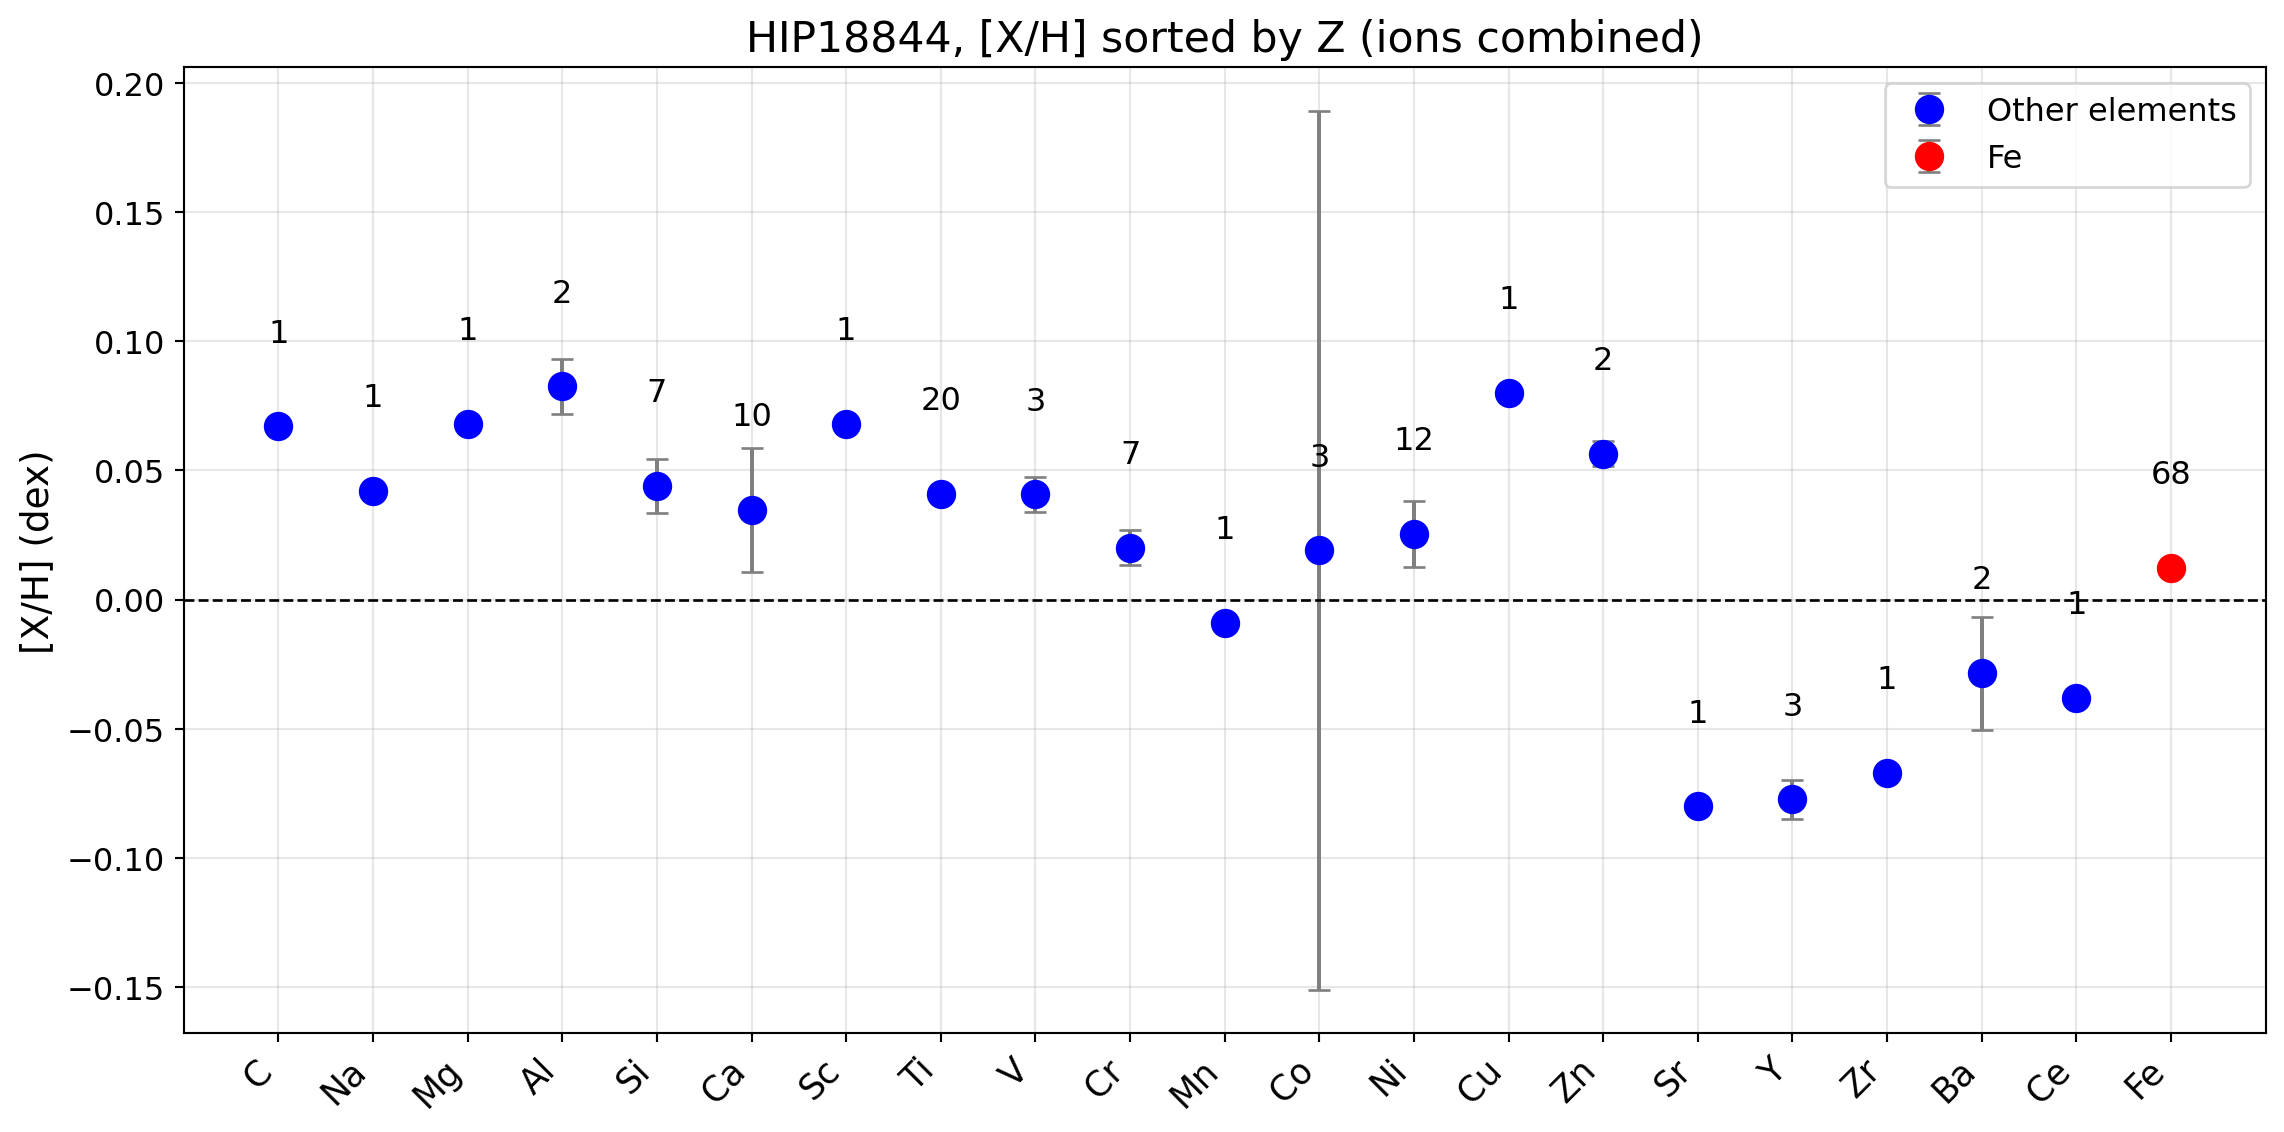

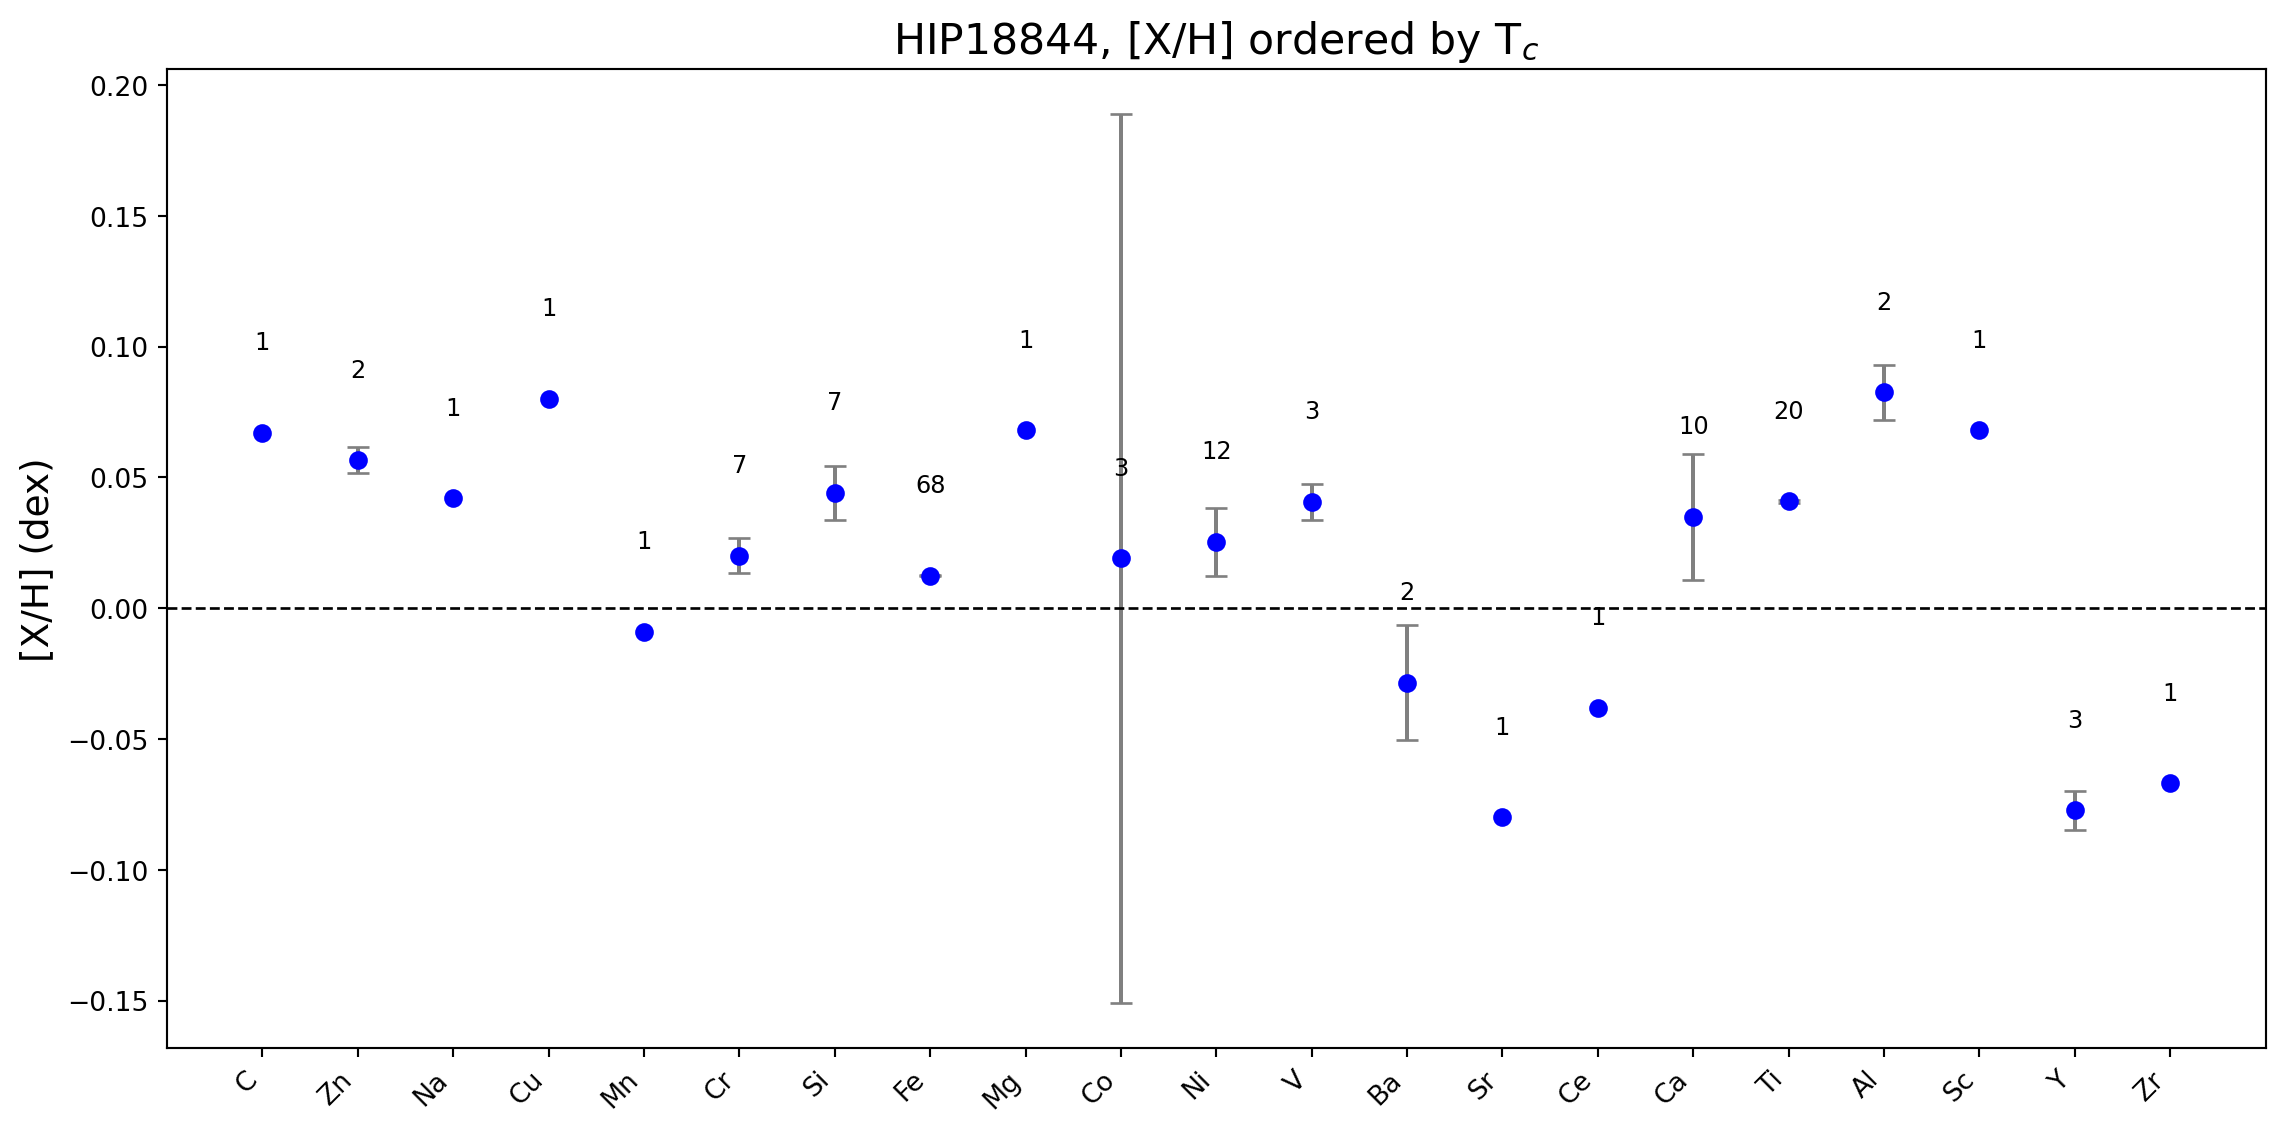

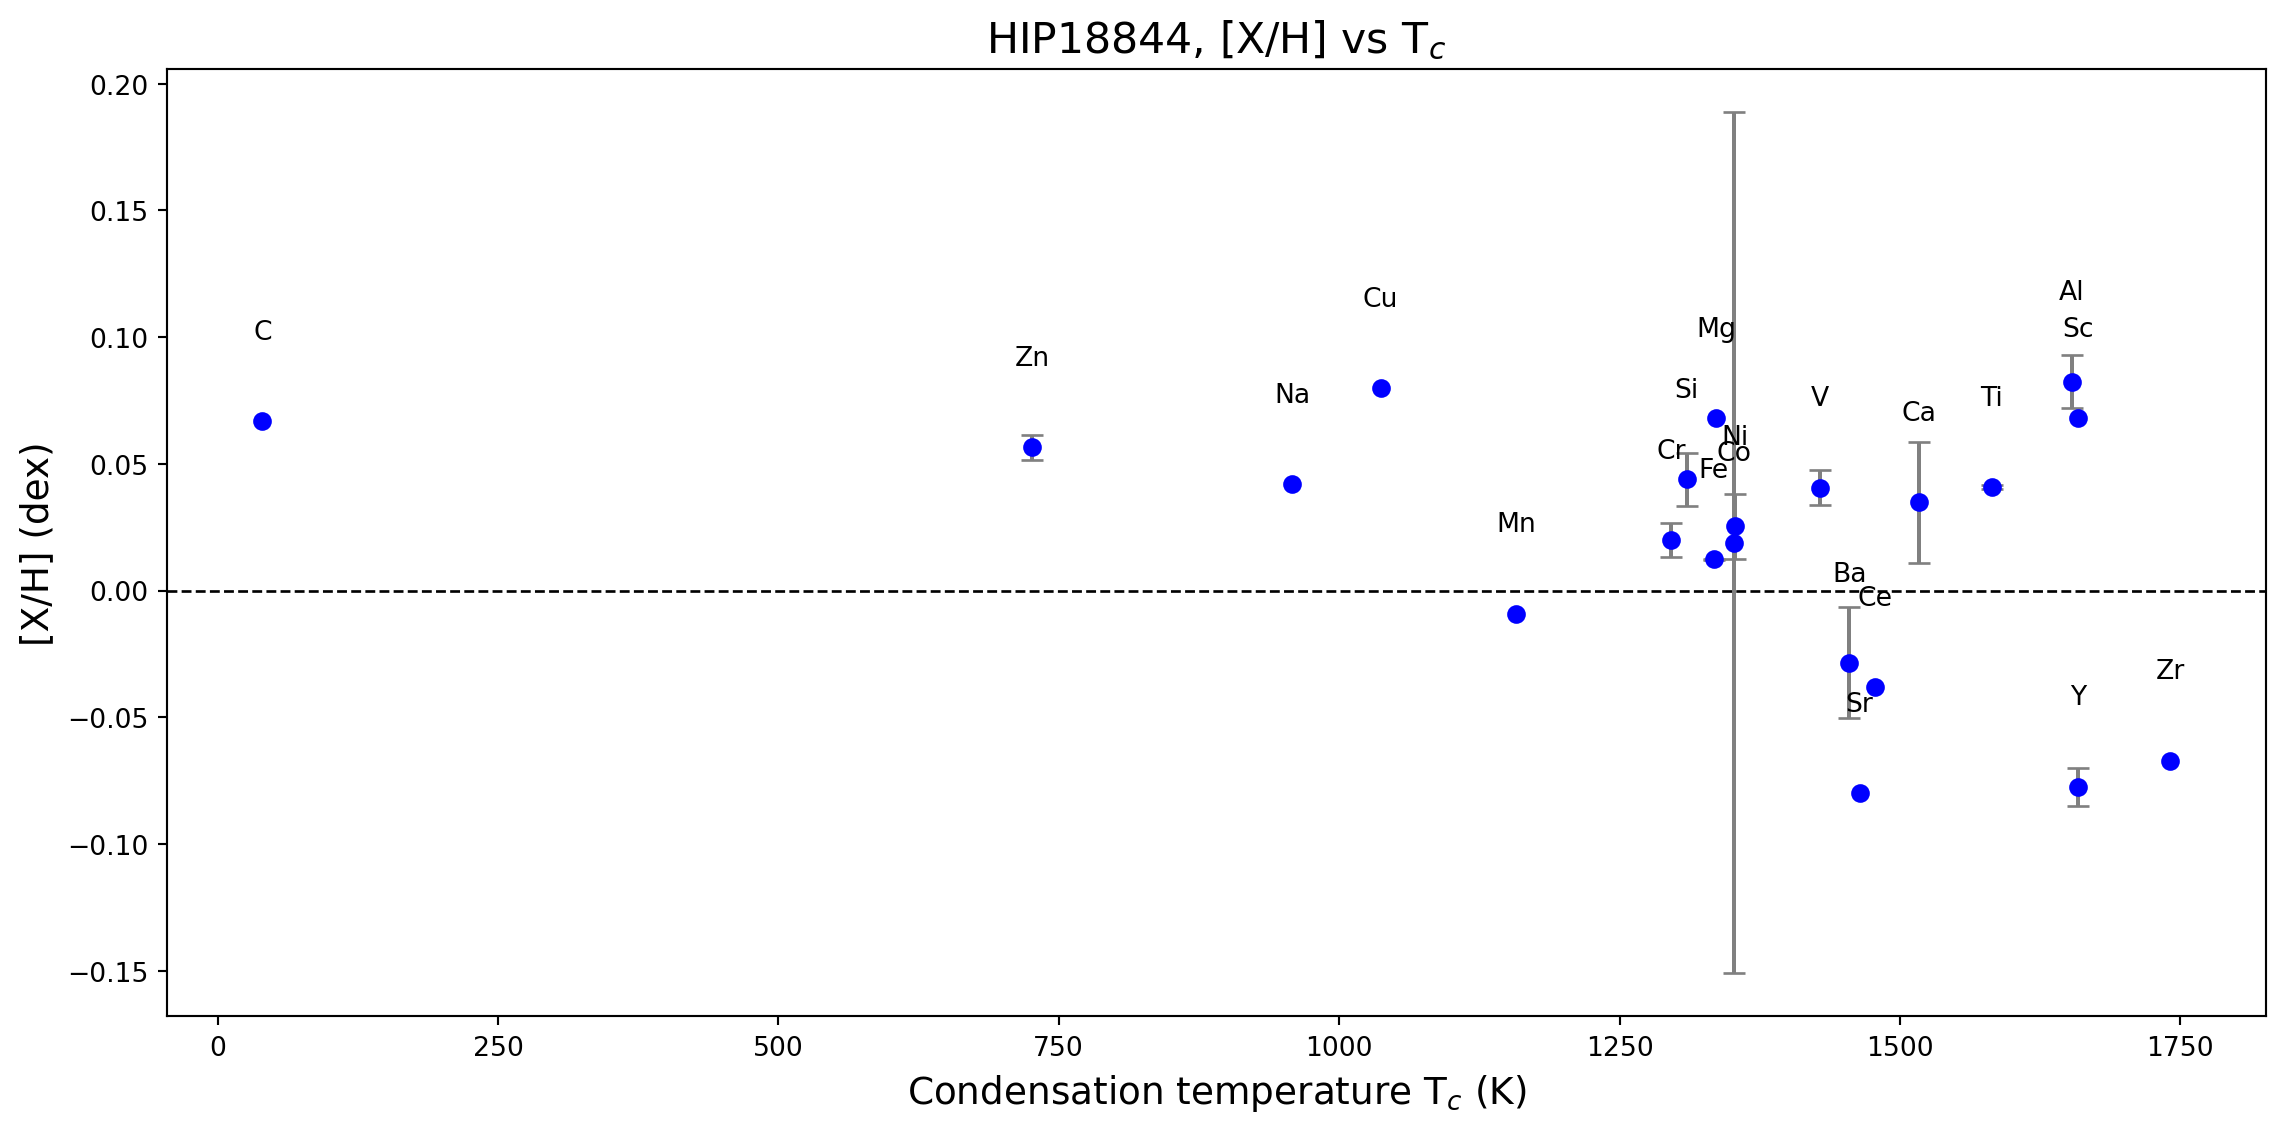

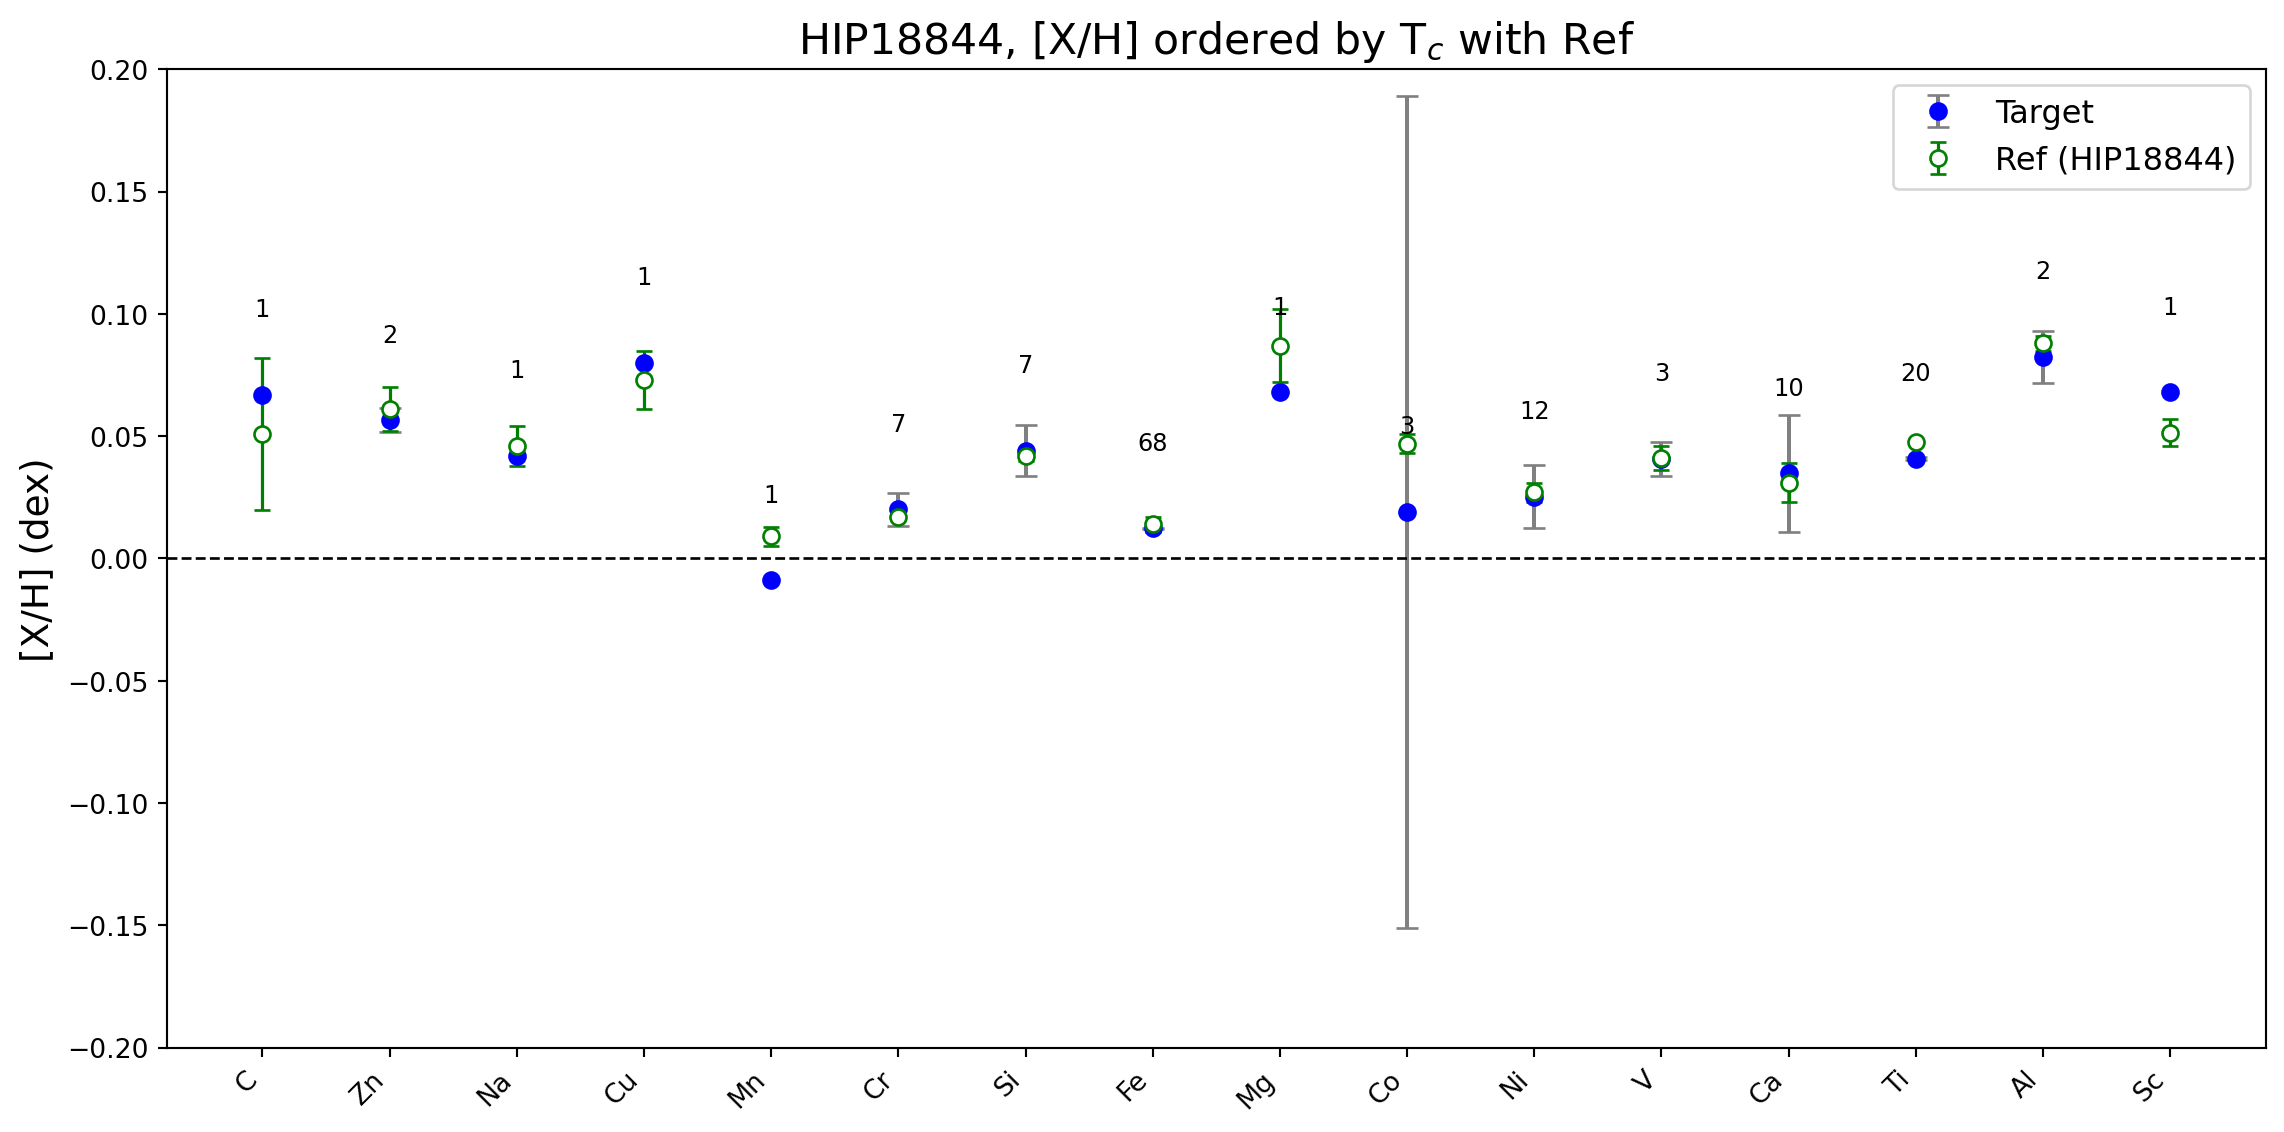

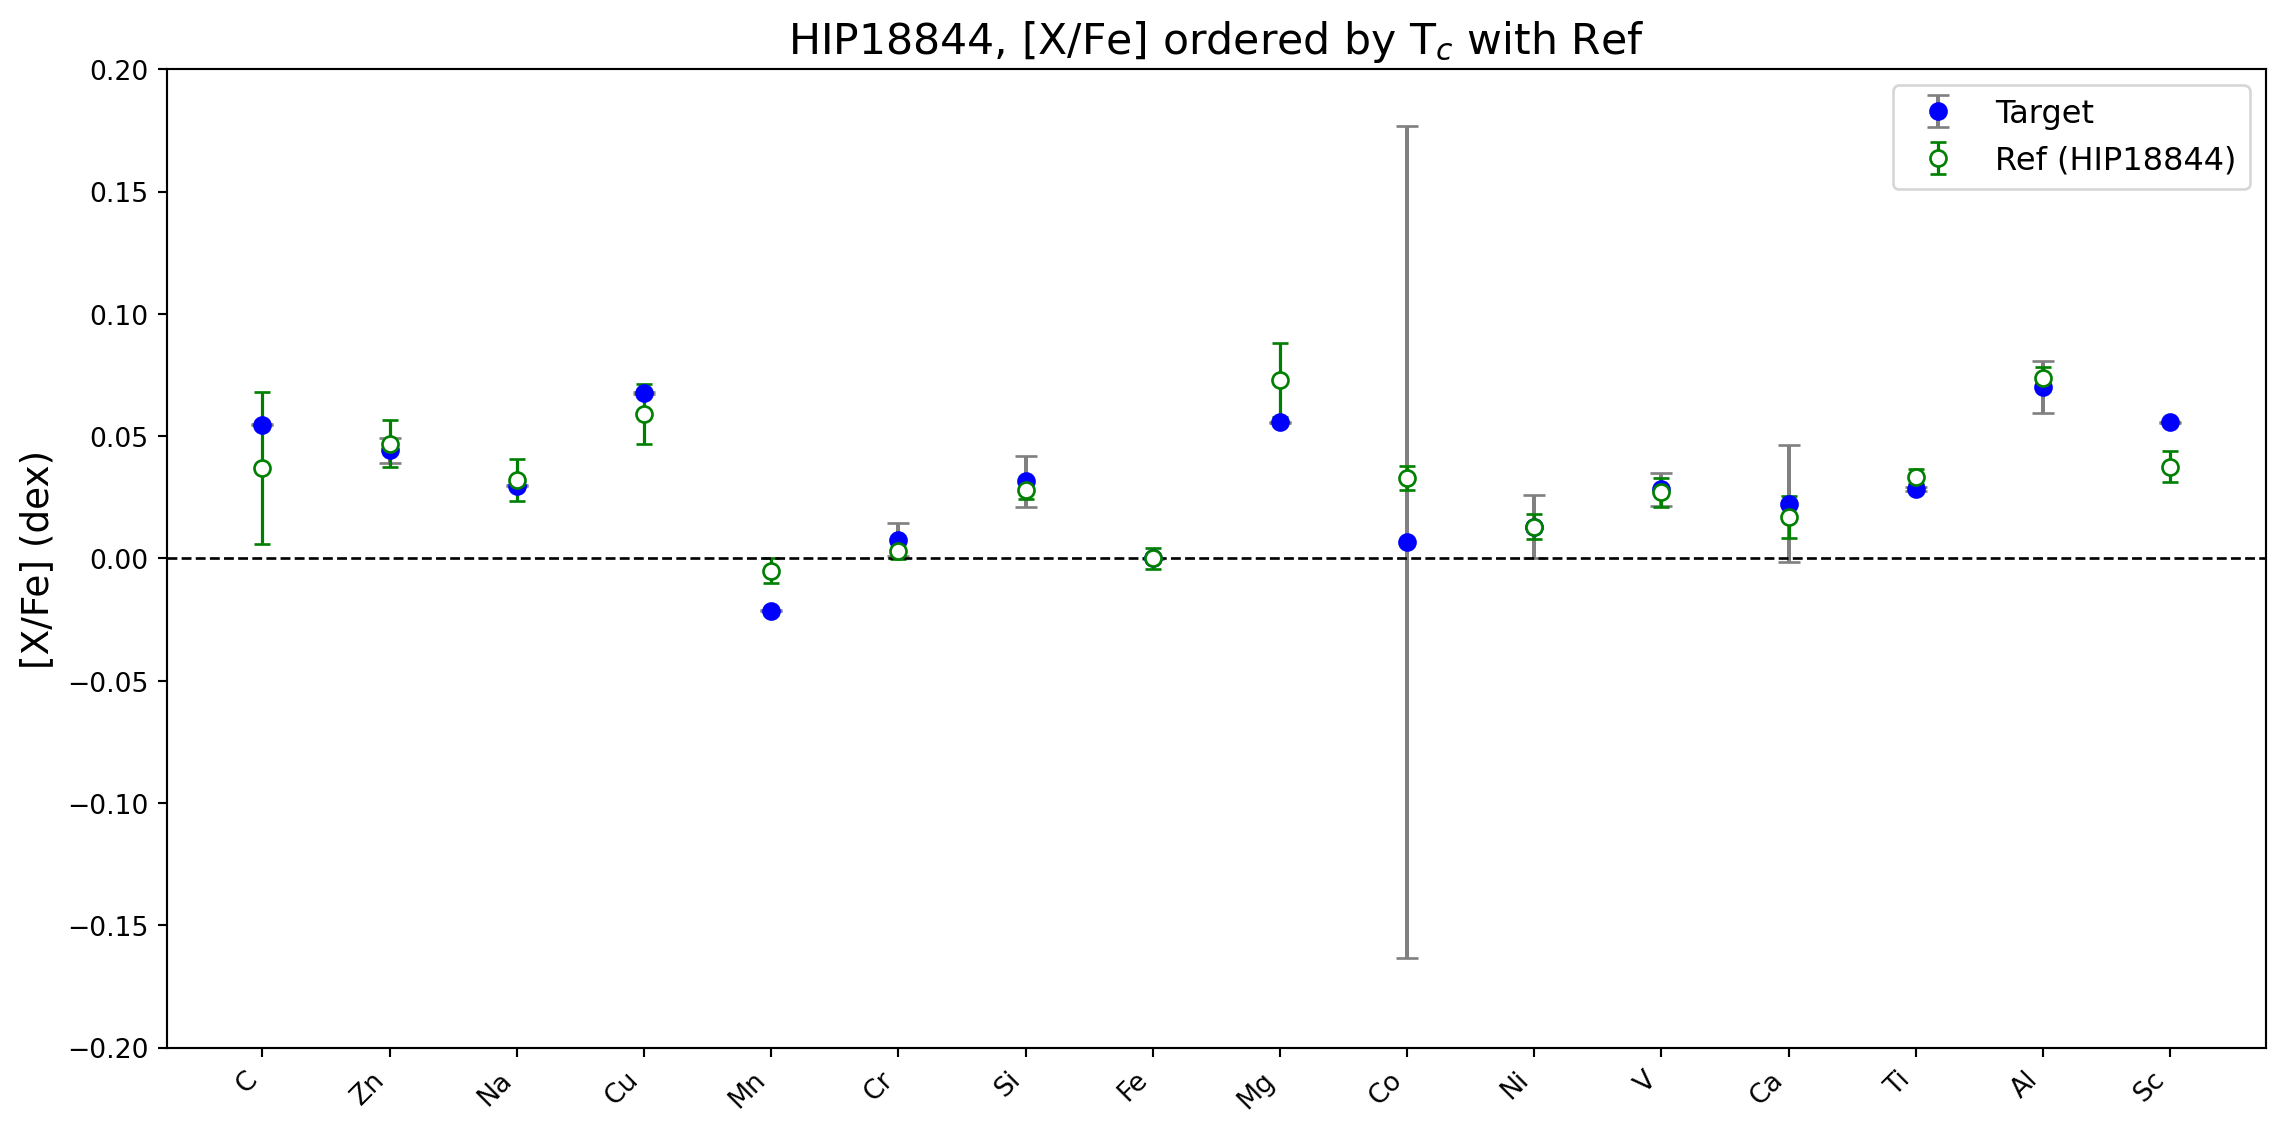

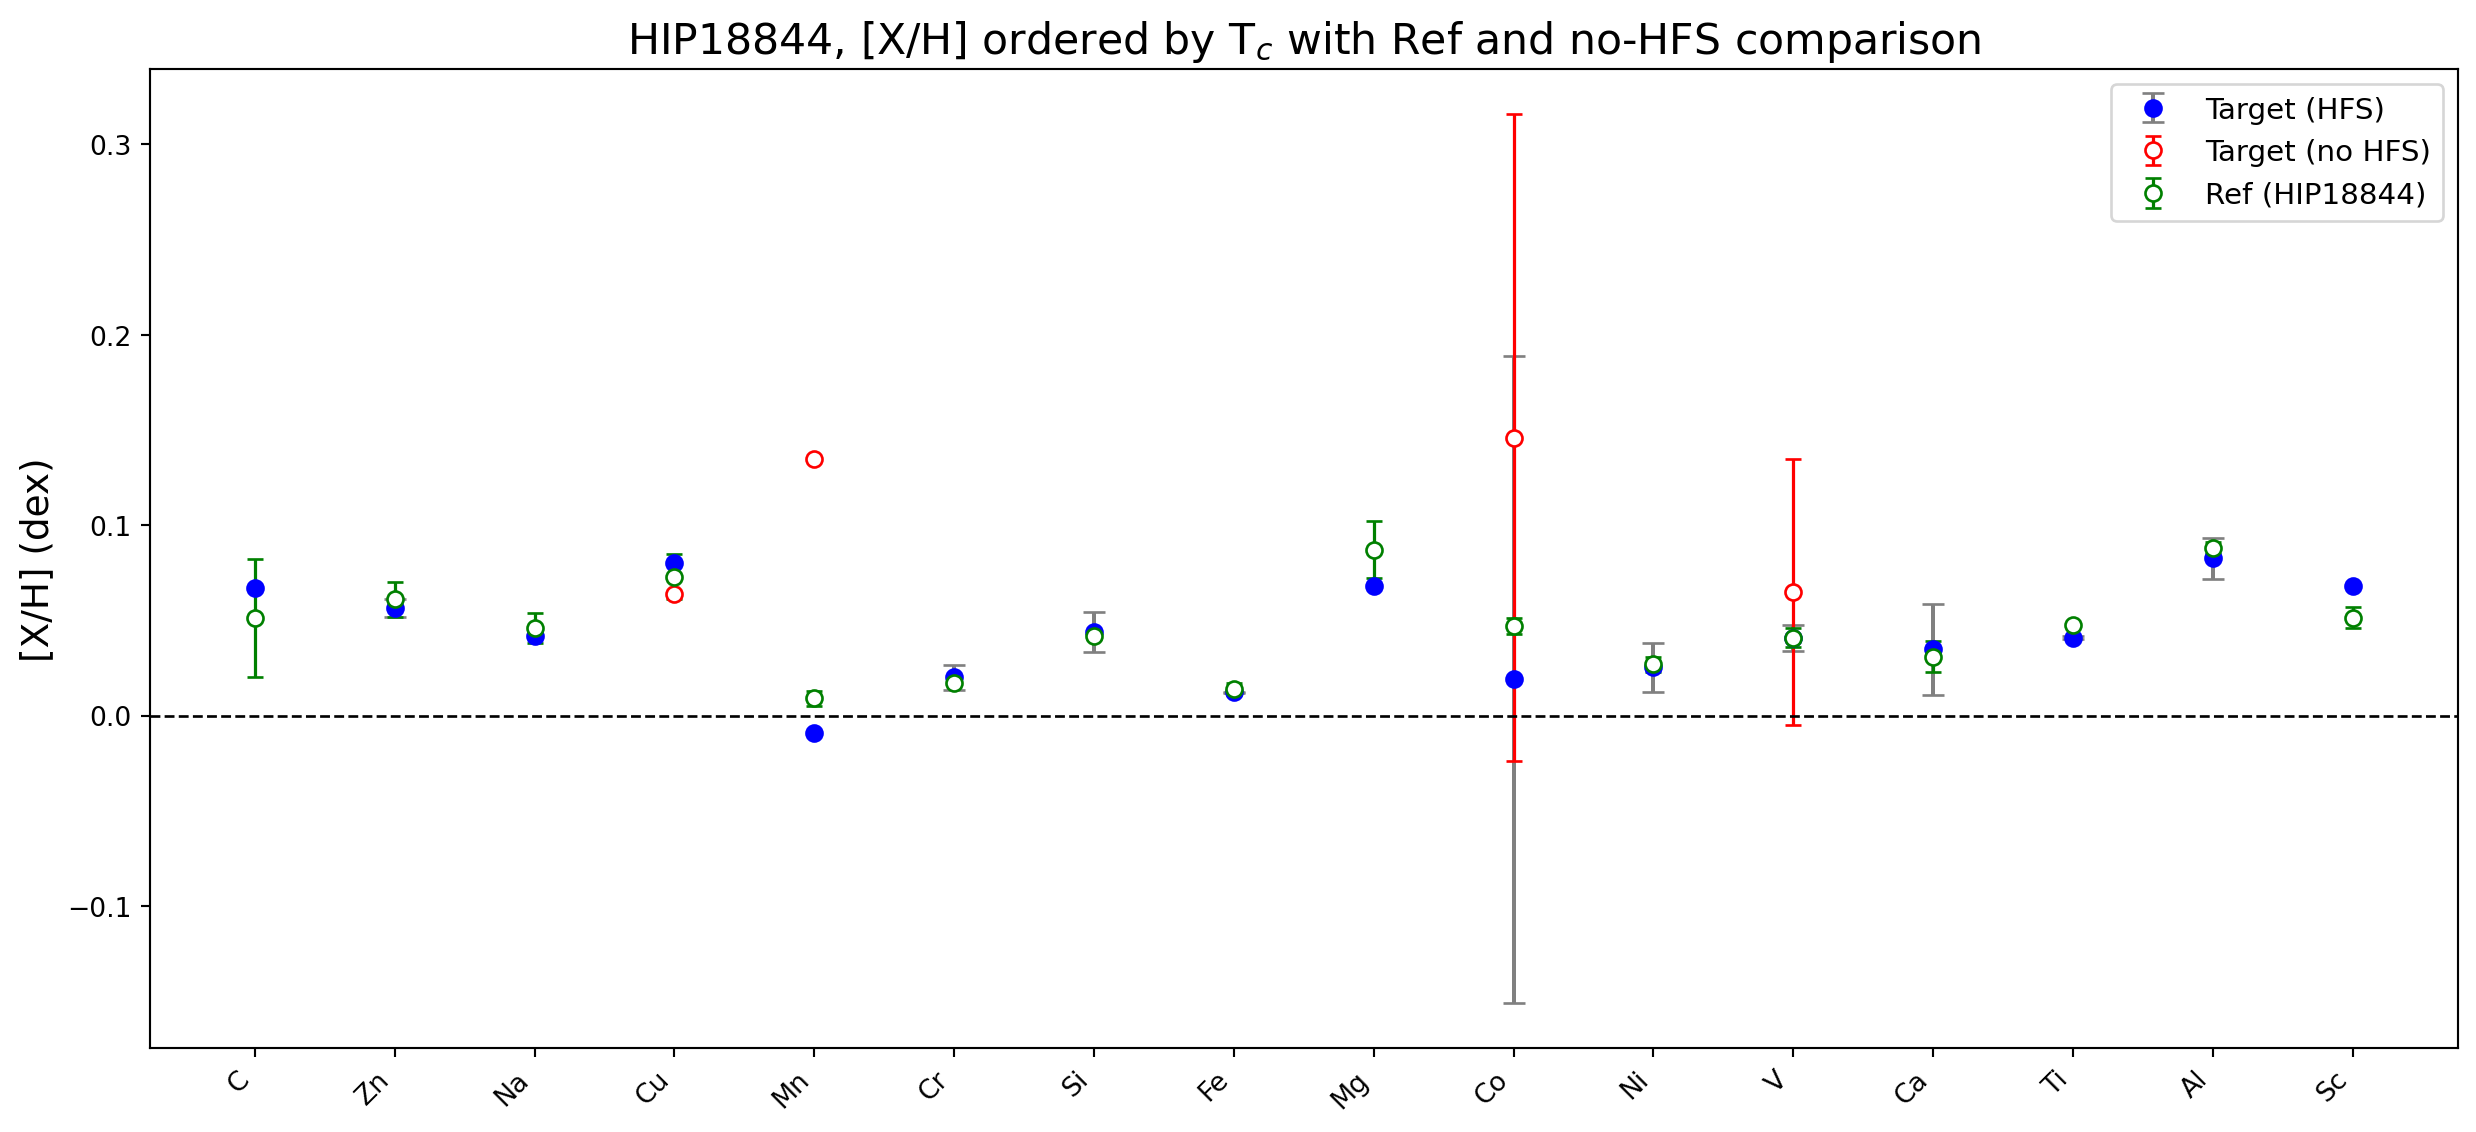

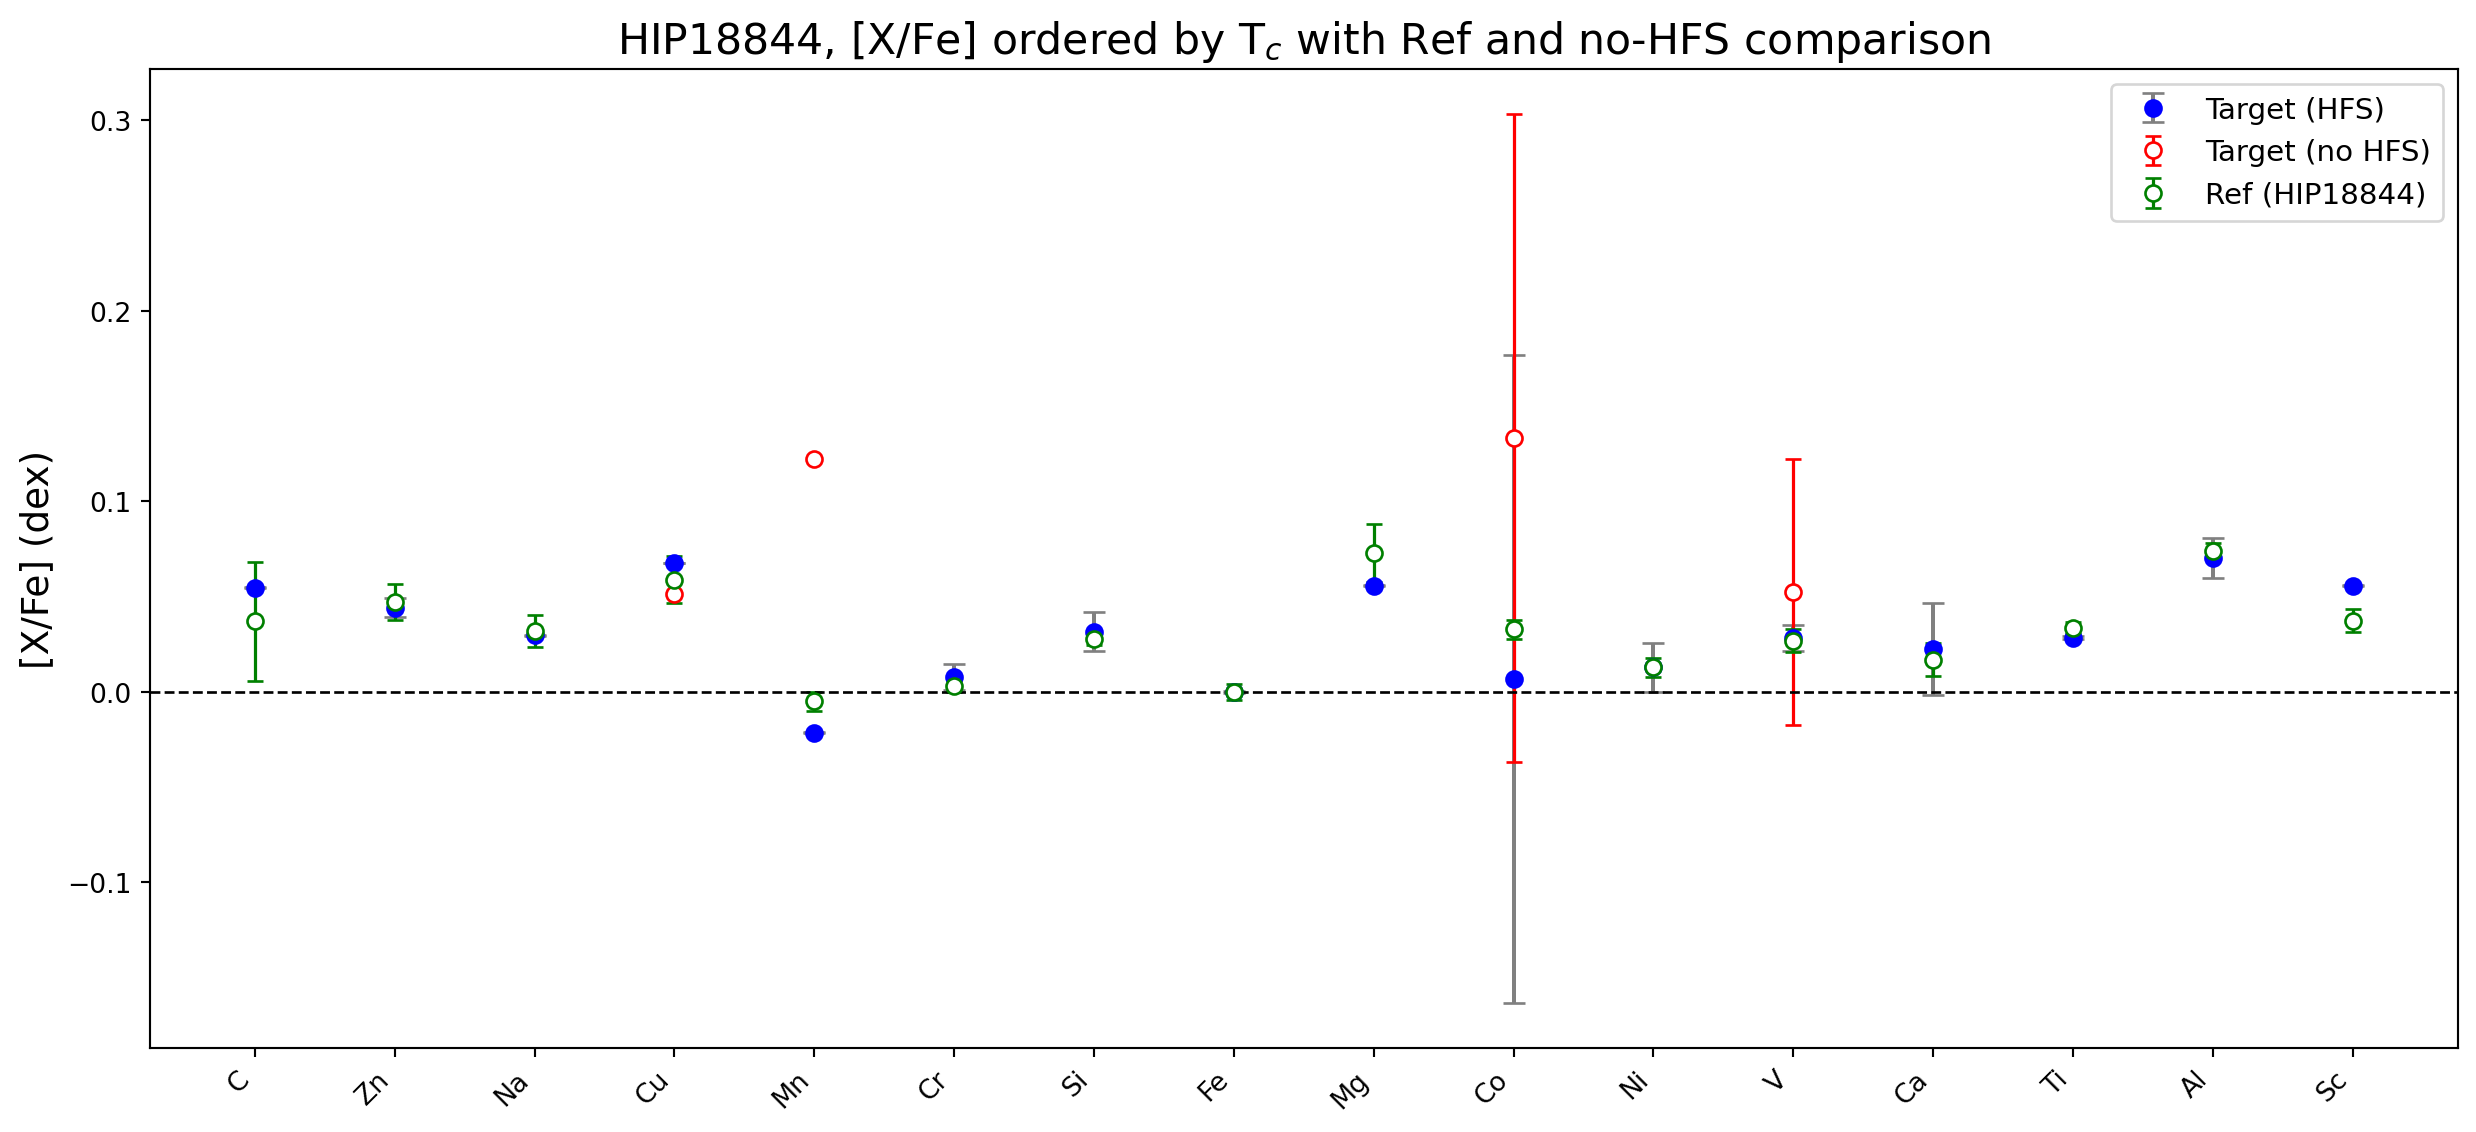

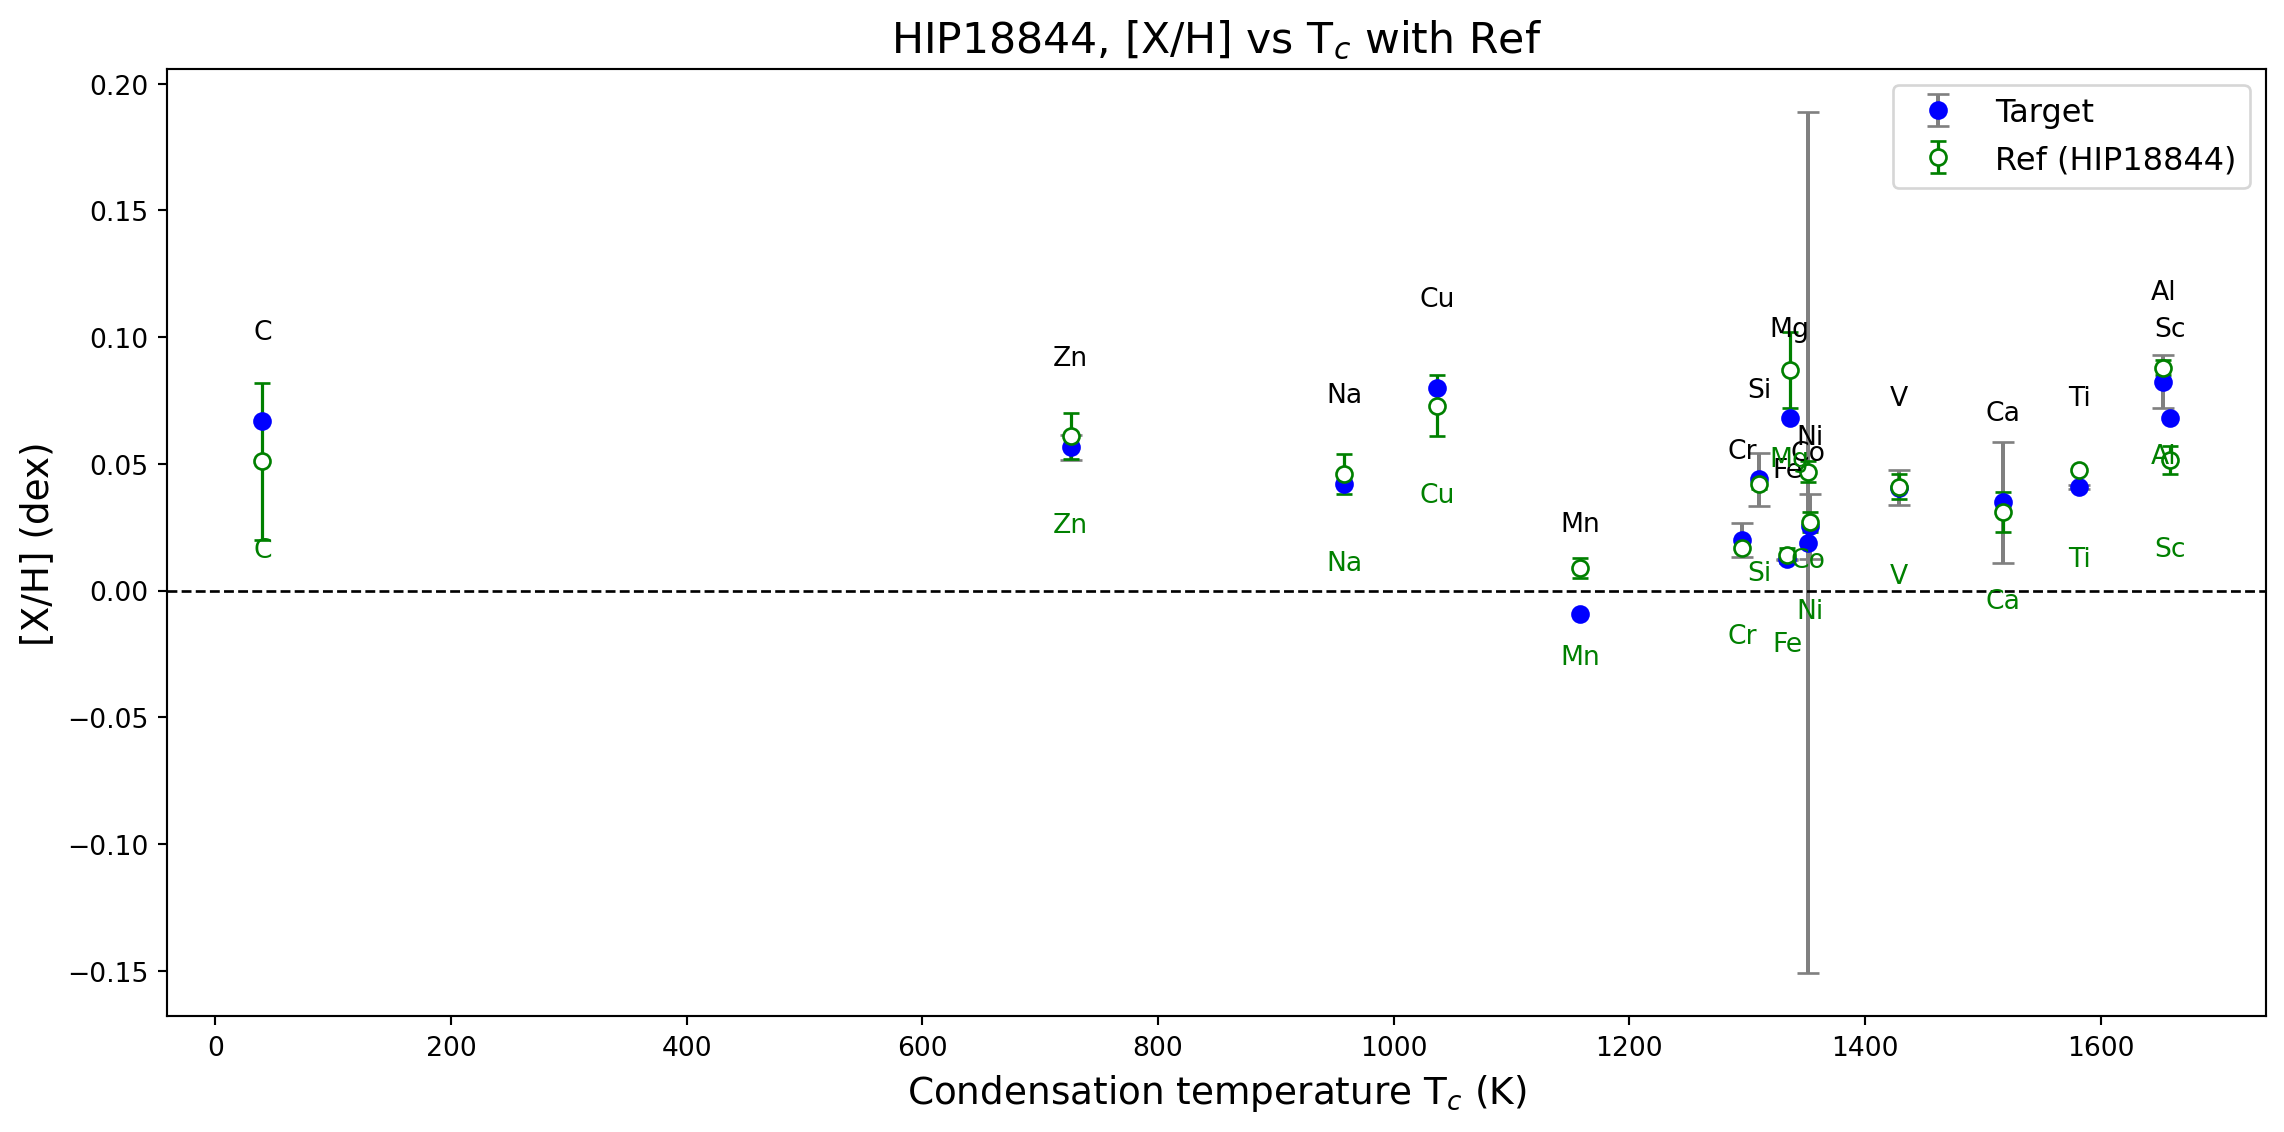

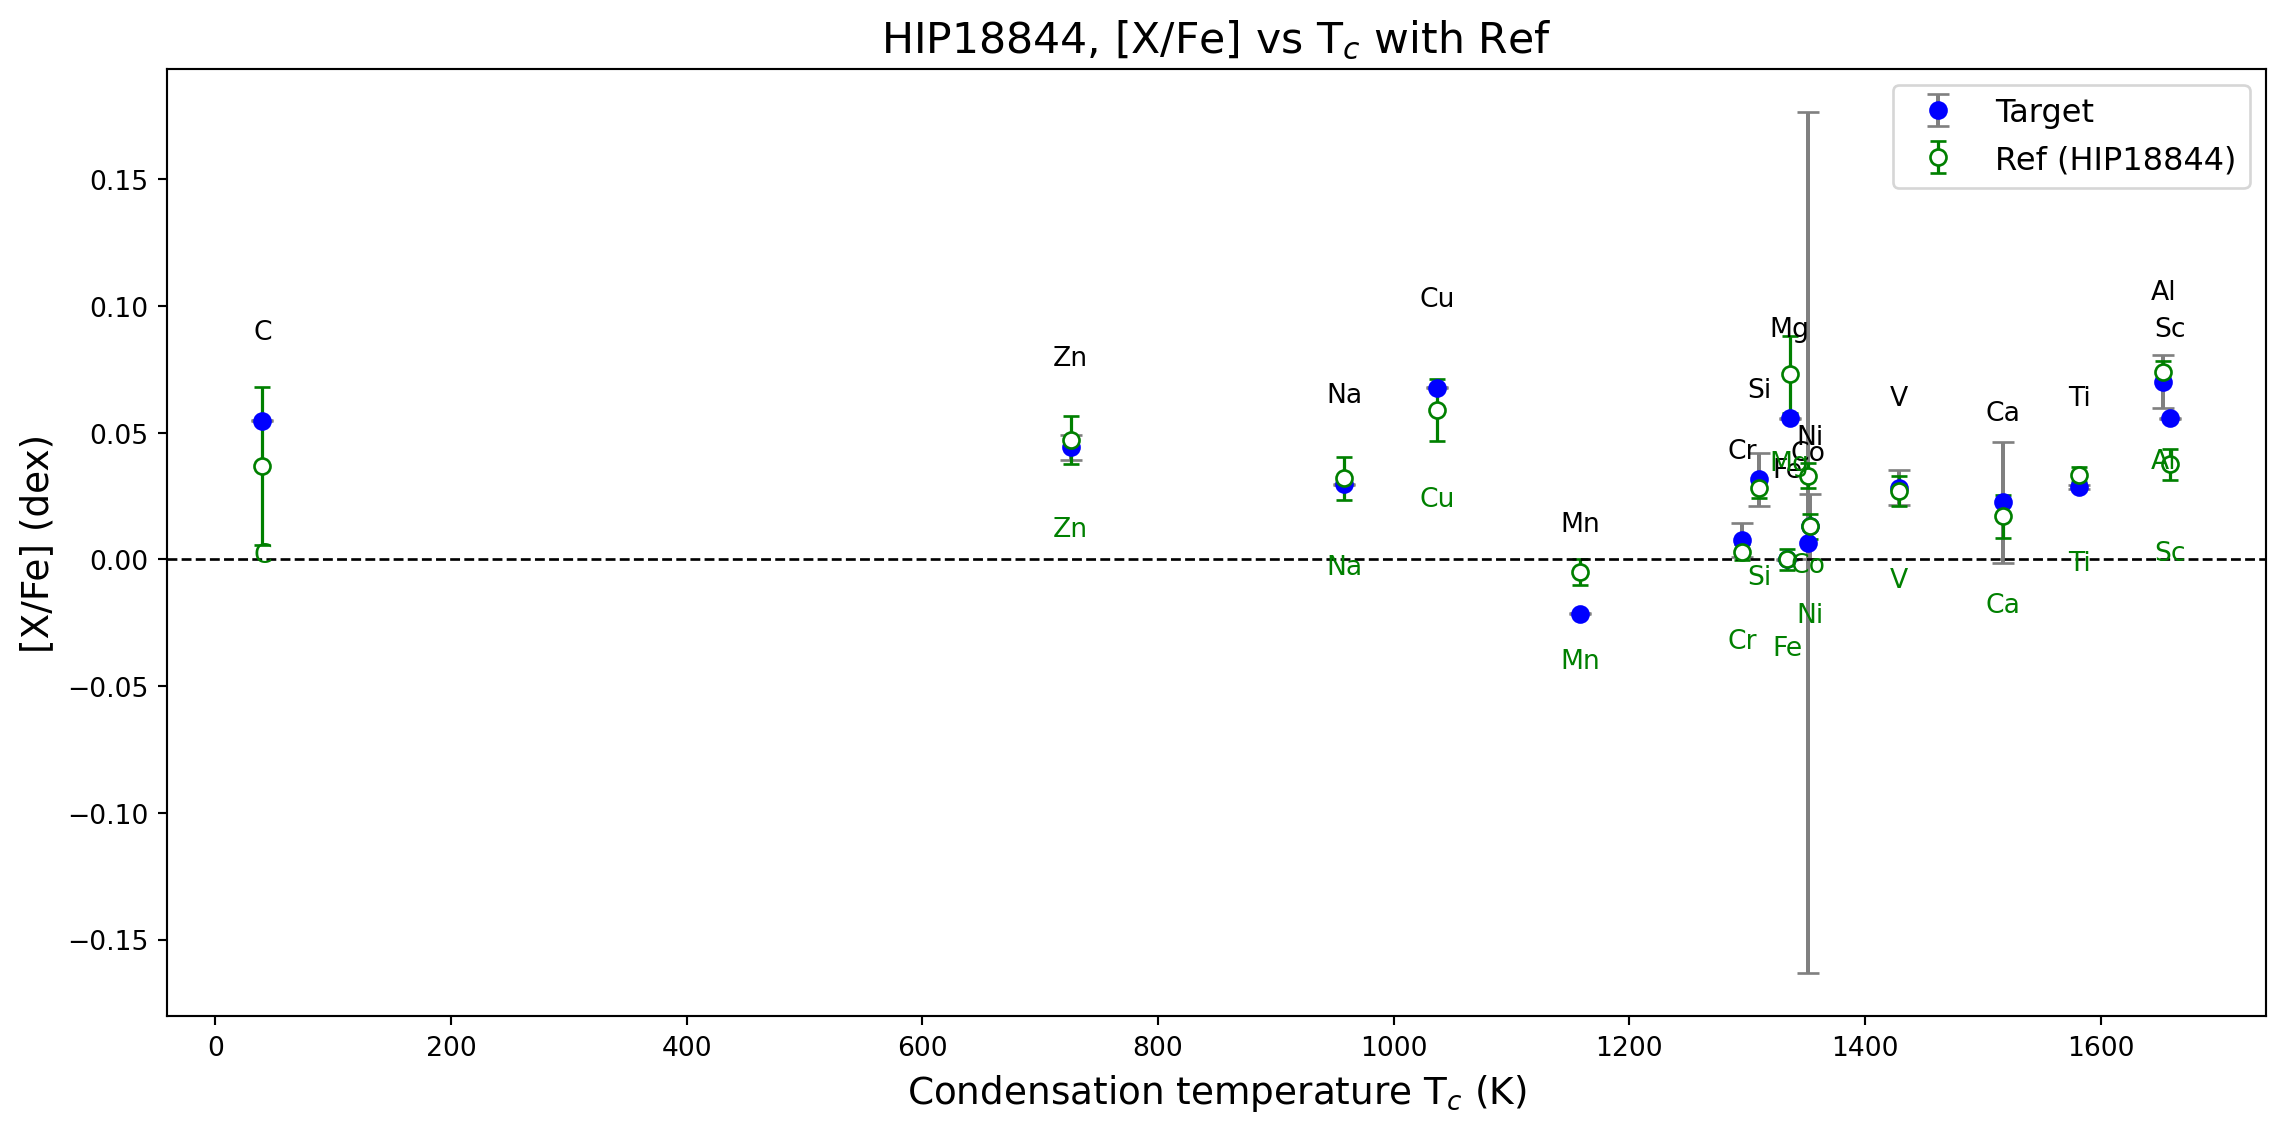

In [3]:
print("[STEP 1] Running step 5 abundance plotting pipeline.")
_plot5 = run_step5_ele_abundance_plots(
    target=target,
    output_abundances_result_path_linebyline_q2=output_abundances_result_path_linebyline_q2,
    abundance_plot_folder=abundance_plot_folder,
    output_folder=output_folder,
    ref_name=REF_NAME,
    ref_star=REF_STAR,
    pipeline_options=PIPELINE_OPTIONS,
    ispec_dir=ispec_dir,
)
print("[STEP 2] Step_element_abundance_plot completed.")
print("[STEP 2] Plot folder:", _plot5["plot_dir"])


## 按 Condensation temperature 排序

### 关于误差
- ref（Meléndez+，A46_table1/2）
    - 输入：
        A46_table1 给 [Fe/H]、e_[Fe/H]；A46_table2 给 [X/Fe]、e_[X/Fe]。
    - 转成 [X/H]:
\begin{equation}
    [X/H] = [X/Fe] + [Fe/H]
\end{equation}
	- 对应误差（独立误差按二范数合成）：
\begin{equation}
    \sigma_{[X/H]} = \sqrt{\sigma_{[X/Fe]}^2 + \sigma_{[Fe/H]}^2}
\end{equation}

- 对电离态先合并（均值 + 电离态间 SEM 作误差）；如需 [X/Fe]，再做差并误差二范数合成。